In [6]:
 #!/usr/bin/env python
from scipy.stats import expon
from scipy.stats import uniform
from scipy.stats import norm
from scipy.stats import multivariate_normal
from numpy.random import multinomial
from numpy.random import uniform
import numpy as np
import matplotlib.pyplot as plt
import scipy 
from scipy.stats import truncnorm
import math
from scipy.stats import mvn
np.set_printoptions(suppress=True)
import pyreadr
import time
import sys

In [14]:
data = pyreadr.read_r('/home/groups/juliapr/Bingjing/code/boundedcoal/syndata/stdsyn2data_2.rda') #args[1] range from 1 to 300
points_inhomo = np.array(data["coal_time"]).squeeze()

In [15]:
points_inhomo=points_inhomo[2]
points_inhomo

array([0.13206616, 0.15644016, 0.24541557, 0.32522736, 0.40704199,
       0.45963871, 0.49146169, 0.51055593, 0.52658637, 0.54953629,
       0.5538428 , 0.58298052, 0.59087066, 0.61671053, 1.00074916,
       1.12010447, 1.31846776, 1.32316591, 1.41582917])

In [16]:
T=7
bin_num=100
#x=np.linspace(T/bin_num/2,T-T/bin_num/2,bin_num)
x=np.linspace(0,T,bin_num+1)[1:bin_num+1] 

def inten2(t):
    return 25*np.exp(-5*t)+1
intensity=inten2(x)


ntip=20


def expo_quad_kernel(xn,xm): # 1,0.1
    return min(xn,xm)

def expo_quad_kernel2(xn,t1,t2): # t1<t2   
    if (xn<=t1):
        return xn*(t2-t1)   
    elif (xn>t1 and xn<t2):
        return -xn**2/2-t1**2/2+xn*t2
    elif (xn>=t2):
        return (t2**2-t1**2)/2

def expo_quad_kernel3(t1,t2,t3,t4): # 1,0.1 #t1<t2, t3<t4
    if (t1==t3 and t2==t4 ):
        return t2**3/3+2*t1**3/3-t1**2*t2/2-t2*t1**2/2
    else:
        return (t4-t3)*(t2**2-t1**2)/2
        

from math import comb
com_vec=np.zeros(ntip-1)
for mmm in range(ntip-1):
    #print(ntip-mmm)
    com_vec[mmm]=comb(ntip-mmm,2)
   


N=(ntip-1)
Ngrid=100
K= ntip-1  # counts of integrals
x4=np.linspace(0,T,Ngrid+1)[1:Ngrid+1] 
xxx=np.concatenate([x4, points_inhomo])

In [17]:
def chol_sample(mean, cov_chol):
    return mean + cov_chol @ np.random.standard_normal(mean.size)

def log_lik(f,ns):
    #ns is # of Ngrids
    if np.prod(f>0)==0:
        return float('-inf') 
    else:
        return np.sum(np.log(f[:,Ngrid:Ngrid+ns])) -np.sum(com_vec*(f[:,(Ngrid+ns):(Nfinal)]))
    

def elliptical_slice(initial_theta,prior,lnpdf,pdf_params=(),
                     cur_lnpdf=None,angle_range=None):
    """
    NAME:
       elliptical_slice
    PURPOSE:
       Markov chain update for a distribution with a Gaussian "prior" factored out
    INPUT:
       initial_theta - initial vector
       prior - cholesky decomposition of the covariance matrix 
               (like what numpy.linalg.cholesky returns), 
               or a sample from the prior
       lnpdf - function evaluating the log of the pdf to be sampled
       pdf_params= parameters to pass to the pdf
       cur_lnpdf= value of lnpdf at initial_theta (optional)
       angle_range= Default 0: explore whole ellipse with break point at
                    first rejection. Set in (0,2*pi] to explore a bracket of
                    the specified width centred uniformly at random.
    OUTPUT:
       new_theta, new_lnpdf
    HISTORY:
       Originally written in matlab by Iain Murray (http://homepages.inf.ed.ac.uk/imurray2/pub/10ess/elliptical_slice.m)
       2012-02-24 - Written - Bovy (IAS)
    """
    D= len(initial_theta)
    if cur_lnpdf is None:
        cur_lnpdf= lnpdf(initial_theta,*pdf_params)

    # Set up the ellipse and the slice threshold
    if len(prior.shape) == 1: #prior = prior sample
        nu= prior
    else: #prior = cholesky decomp
        if not prior.shape[0] == D or not prior.shape[1] == D:
            raise IOError("Prior must be given by a D-element sample or DxD chol(Sigma)")
        nu= np.dot(prior,np.random.normal(size=D))
    hh = math.log(np.random.uniform()) + cur_lnpdf

    # Set up a bracket of angles and pick a first proposal.
    # "phi = (theta'-theta)" is a change in angle.
    if angle_range is None or angle_range == 0.:
        # Bracket whole ellipse with both edges at first proposed point
        phi= np.random.uniform()*2.*math.pi
        phi_min= phi-2.*math.pi
        phi_max= phi
    else:
        # Randomly center bracket on current point
        phi_min= -angle_range*np.random.uniform()
        phi_max= phi_min + angle_range
        phi= np.random.uniform()*(phi_max-phi_min)+phi_min

    # Slice sampling loop
    while True:
        # Compute xx for proposed angle difference and check if it's on the slice
        xx_prop = initial_theta*math.cos(phi) + nu*math.sin(phi)
        cur_lnpdf = lnpdf(xx_prop,*pdf_params)
        if cur_lnpdf > hh:
            # New point is on slice, ** EXIT LOOP **
            break
        # Shrink slice to rejected point
        if phi > 0:
            phi_max = phi
        elif phi < 0:
            phi_min = phi
        else:
            raise RuntimeError('BUG DETECTED: Shrunk to current position and still not acceptable.')
        # Propose new angle difference
        phi = np.random.uniform()*(phi_max - phi_min) + phi_min
    return (xx_prop,cur_lnpdf)

days=np.concatenate([np.zeros(1),points_inhomo])
days
diff=np.diff(days)


Nfinal=Ngrid+N+K
g_mk=1+np.zeros(Nfinal)
g_mk[ Ngrid+N:Ngrid+N+K ]=1*days[N]*diff/sum(diff)

nsim1=800000
nsim2=300000


cov_K=np.zeros((Nfinal,Nfinal))


theta=np.exp(4)
rem=1
alpha=.1
beta=.1

for i in range(Nfinal):
        for j in range(i,Nfinal):
            if (j<Ngrid+N) and (i<Ngrid+N):
                cov_K[i][j]=expo_quad_kernel(xxx[i],xxx[j])
            if (j>(Ngrid+N-1)) and (i<(Ngrid+N)):
                cov_K[i][j]=expo_quad_kernel2(xxx[i],   days[  j-Ngrid-N  ], days[  j-Ngrid-N+1           ]    )
            if  (i>(Ngrid+N-1)):
                cov_K[i][j]=expo_quad_kernel3(days[i-Ngrid-N],days[i-Ngrid-N+1],  days[j-Ngrid-N],days[j-Ngrid-N+1 ]          )  
            if j!=i:
                cov_K[j][i]=cov_K[i][j]

noise_var=1e-6

cov_K_inv=np.linalg.inv(cov_K+np.eye(Nfinal)*noise_var)

In [18]:
ones_vec=np.ones(Nfinal)

ones_vec[(Ngrid+N):Nfinal]=diff

ones_vec=ones_vec.reshape(Nfinal,1)

cov_K_mod_inv=cov_K_inv-cov_K_inv@ones_vec@ones_vec.transpose()@cov_K_inv/(ones_vec.transpose()@cov_K_inv@ones_vec)

#=cov_K_mod_inv
#cov_K_mod_inv_add[0,0]=cov_K_mod_inv_add[0,0]+1e-7

cov_K_mod_inv_add=cov_K_mod_inv+np.eye(Nfinal)*noise_var

cov_K_mod=np.linalg.inv(cov_K_mod_inv_add)

cov_K_mod_chol=np.linalg.cholesky(cov_K_mod) 

In [32]:
cov_K@cov_K_inv

array([[ 0.99988154, -0.        , -0.        , ...,  0.        ,
        -0.        ,  0.        ],
       [-0.        ,  0.99970803,  0.        , ..., -0.        ,
        -0.        ,  0.        ],
       [-0.        ,  0.        ,  0.99984006, ...,  0.        ,
        -0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.98661417,
         0.00000091,  0.        ],
       [ 0.        ,  0.        , -0.        , ...,  0.00000091,
         0.00857848,  0.00000027],
       [-0.        ,  0.        ,  0.        , ...,  0.        ,
         0.00000027,  0.96660415]])

In [20]:
for ite in range(nsim1):
    if (ite%100000==0):
        print(ite)#cov_K is the covariance matrix
    cov_K_chol_final=cov_K_mod_chol/np.sqrt(theta)
    prior=chol_sample(mean=np.zeros(Nfinal), cov_chol=cov_K_chol_final)#nu
    g_mk,curloglike=elliptical_slice(g_mk.reshape(1,-1),prior,log_lik,pdf_params=[N],cur_lnpdf=None,angle_range=None)
    alpha_pos=alpha+Nfinal/2
    beta_pos=beta+1/2*g_mk[0]@cov_K_mod_inv@g_mk[0]
    theta=np.random.gamma(alpha_pos, 1/beta_pos,1)
  

0
100000
200000
300000
400000
500000
600000
700000


In [25]:
# g_mk_list=[]
g_mk_list2=[]
g_mk_list3=[]
theta_list=[]
#theta=0.01


for ite in range(nsim2):
    if (ite%100000==0):
        print(ite)#cov_K is the covariance matrix
    cov_K_chol_final=cov_K_mod_chol/np.sqrt(theta)
    prior=chol_sample(mean=np.zeros(Nfinal), cov_chol=cov_K_chol_final)#nu
    g_mk,curloglike=elliptical_slice(g_mk.reshape(1,-1),prior,log_lik,pdf_params=[N],cur_lnpdf=None,angle_range=None)
    g_mk_list2.append(g_mk[0][0:Ngrid])
    g_mk_list3.append(g_mk[0][Ngrid:Nfinal])
    alpha_pos=alpha+Nfinal/2
    beta_pos=beta+1/2*g_mk[0]@cov_K_mod_inv@g_mk[0]
    theta=np.random.gamma(alpha_pos, 1/beta_pos,1)
    theta_list.append(theta)    #print(beta_pos)
        #print(theta)



0
100000
200000


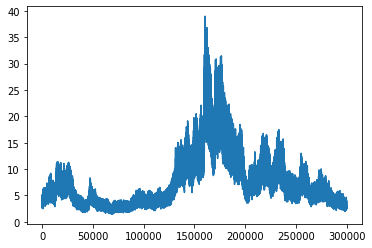

In [26]:
plt.plot(theta_list)

Text(0.5, -0.2, 'latent GP at midpoint')

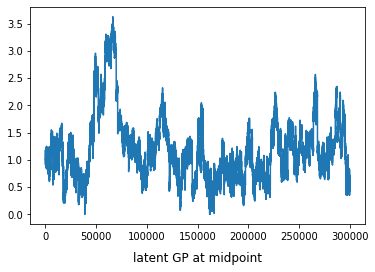

In [27]:
plt.figure()
plt.plot(np.array(g_mk_list2)[:,40])

plt.title('latent GP at midpoint',y=-0.2)

In [31]:
cov_K.min()

1.0218347314350229e-05

Text(0, 0.5, 'Latent GP $\\lambda(s)$')

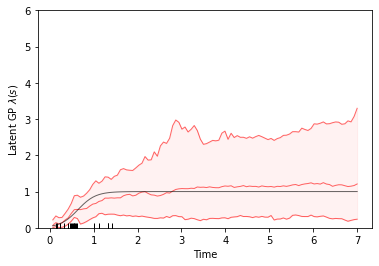

In [30]:
low=np.quantile(g_mk_list2, 0.025, axis=0)
high=np.quantile(g_mk_list2, 0.975, axis=0)
me=np.quantile(g_mk_list2, 0.5, axis=0)

fig, ax = plt.subplots()

ax.plot(x4,me,'-',lw=1,alpha=0.6,c='r')
ax.plot(x4,low,'-',lw=1,alpha=0.6,c='r',label='Mixed: 2.5%-50%-97.5% Quantiles')
ax.plot(x4,high,'-',lw=1,alpha=0.6,c='r')
ax.fill_between(x4, low, high, color='r', alpha=.05)
#plt.xlabel("t",y=-0.3)

plt.plot(x,1/intensity,'k-',lw=1,alpha=0.6,label='Truth')
plt.plot(points_inhomo,np.zeros(len(points_inhomo)),linestyle='None', marker='|', color='k', markersize=10,label='events')
#plt.xlabel("t",y=-0.3)
plt.ylim(0,6)
plt.xlabel('Time')
plt.ylabel(r'Latent GP $\lambda(s)$')
#plt.title('Mixed and Recurrent Earthquake Datasets with RI-BM Fit')